# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [ ]:
print(f"Số dòng và số cột: {df.shape}")
print(f"Danh sách tên cột: {df.columns.tolist()}")
print(f"Kiểu dữ liệu:\n{df.dtypes}")

## A.2. Missing values & Duplicate data

In [ ]:
print("Số giá trị thiếu ở mỗi cột:")
print(df.isnull().sum())

print(f"Số dòng trùng lặp (Duplicate): {df.duplicated().sum()}")

## A.3. Invalid values

In [14]:
print("age <= 0:", (df['age']<=0).sum())
print("age is null", (df['age'].isnull().sum()))
print("deck is null", (df['deck'].isnull().sum()))
print("pclass <= 0:", (df['pclass']<=0).sum())
print("embarked is null", (df['embarked'].isnull().sum()))
print("alone is null", (df['alone'].isnull().sum()))


age <= 0: 0
age is null 177
deck is null 688
pclass <= 0: 0
embarked is null 2
alone is null 0


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [15]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
display(df)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [16]:
cols = ['age', 'fare', 'family_size']
for col in cols:
    _mean = df[col].mean()
    _median = df[col].median()
    _mode = df[col].mode()[0]
    print(f"[{col}] Mean: {_mean: .2f} | Median: {_median: .2f} | Mode: {_mode: .2f}")



[age] Mean:  29.70 | Median:  28.00 | Mode:  24.00
[fare] Mean:  32.20 | Median:  14.45 | Mode:  8.05
[family_size] Mean:  1.90 | Median:  1.00 | Mode:  1.00


## Group 2 — Dispersion

In [17]:
for col in ['age', 'fare', 'family_size']:
    s = df[col]
    range_ = s.max() - s.min()
    std_ = s.std()
    var_ = s.var()
        
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr_ = q3 - q1
         
    cv_ = std_ / s.mean()
     
    print(f"--- {col} ---")
    print(f"Range = {range_:.2f}, Std = {std_:.2f},Var = {var_:.2f} IQR = {iqr_:.2f}, CV = {cv_:.2f}")


--- age ---
Range = 79.58, Std = 14.53,Var = 211.02 IQR = 17.88, CV = 0.49
--- fare ---
Range = 512.33, Std = 49.69,Var = 2469.44 IQR = 23.09, CV = 1.54
--- family_size ---
Range = 10.00, Std = 1.61,Var = 2.60 IQR = 1.00, CV = 0.85


## Group 3 — Location and Shape

--- age ---
P25 = 20.12, P50 = 28.00, P75 = 38.00
Skewness = 0.39, Kurtosis = 0.17

--- fare ---
P25 = 7.91, P50 = 14.45, P75 = 31.00
Skewness = 4.78, Kurtosis = 33.20



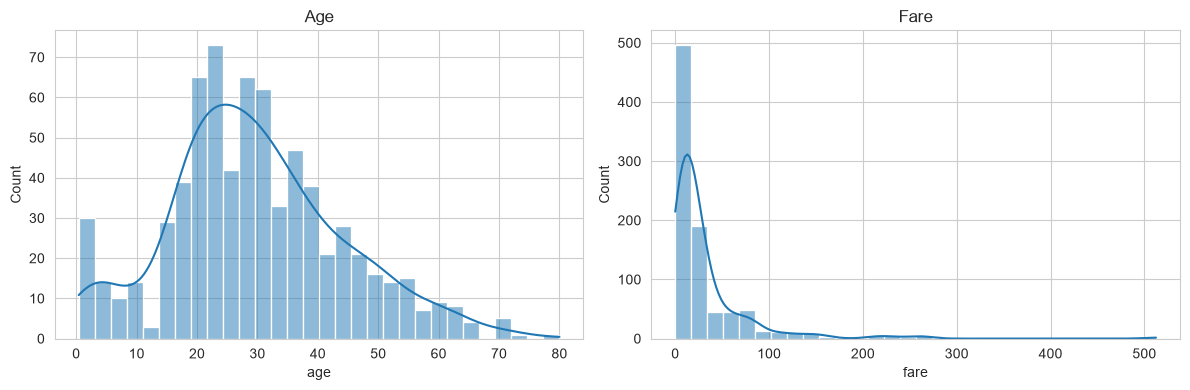

In [18]:

for col in ['age', 'fare']:
    s = df[col].dropna()
    skew_val = stats.skew(s)
    kurt_val = stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25 = {s.quantile(0.25):.2f}, P50 = {s.quantile(0.5):.2f}, P75 = {s.quantile(0.75):.2f}")
    print(f"Skewness = {skew_val:.2f}, Kurtosis = {kurt_val:.2f}\n")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['age'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age')

sns.histplot(df['fare'].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Fare')

plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [19]:
survival_pclass = df.groupby('pclass')['survived'].mean() * 100

diff = survival_pclass.max() - survival_pclass.min()

print("---TỈ LỆ SỐNG SÓT THEO HẠNG VÉ")
display(survival_pclass.round(2))
print(f"\n=> Hạnh vé hạng nhấtnhất chênh lệch {diff:.2f}% so với hạng thấp nhất - vé hang 3")

---TỈ LỆ SỐNG SÓT THEO HẠNG VÉ


pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64


=> Hạnh vé hạng nhấtnhất chênh lệch 38.73% so với hạng thấp nhất - vé hang 3


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [22]:
sex_pclass_table = df.pivot_table(index='sex', columns='pclass', values='survived', aggfunc='mean') * 100

print("---TỶ LỆ SỐNG SÓTTHEO GIỚI TÍNH VÀ HẠNG VÉ---")
display(sex_pclass_table.round(2))

---TỶ LỆ SỐNG SÓTTHEO GIỚI TÍNH VÀ HẠNG VÉ---


pclass,1,2,3
sex,,,
female,96.81,92.11,50.00
male,36.89,15.74,13.54


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [24]:
fare_survival = df.groupby('survived')['fare'].mean()

print("--- GIÁ VÉ TRUNG BÌNH THEO TÌNH TRẠNG SỐNG SÓT---")
display(fare_survival.round(2))



--- GIÁ VÉ TRUNG BÌNH THEO TÌNH TRẠNG SỐNG SÓT---


survived
0    22.12
1    48.40
Name: fare, dtype: float64

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [25]:
family_survival = df.groupby('family_size')['survived'].agg(['count', 'mean'])
family_survival['mean'] = family_survival['mean'] * 100
family_survival.columns = ['Số lượng người', 'Tỷ lệ sống sót']

print("---TỶ LỆ SỐNG SÓT THEO QUY MÔ GIA ĐÌNH---")
display(family_survival.round(2))


---TỶ LỆ SỐNG SÓT THEO QUY MÔ GIA ĐÌNH---


,Số lượng người,Tỷ lệ sống sót
family_size,,
1,537,30.35
2,161,55.28
3,102,57.84
4,29,72.41
5,15,20.00
6,22,13.64
7,12,33.33
8,6,0.00
11,7,0.00


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [26]:
embark_survival = df.groupby('embark_town')['survived'].mean().sort_values(ascending=False) * 100

print("TỶ LỆ SỐNG SÓT THEO CẢNG LÊN TÀU---")
display(embark_survival.round(2))


TỶ LỆ SỐNG SÓT THEO CẢNG LÊN TÀU---


embark_town
Cherbourg      55.36
Queenstown     38.96
Southampton    33.70
Name: survived, dtype: float64

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

1. Hạng vé và giá vé càng cao thì tỉ lệ sống sót của người trong hạng đó càng cao. Vé hạng nhất có tỉ lệ sống sót cao hơn gấp 3 lần so với nguwfi ở vé hạng 3
2. Phụ nữ có cơ hội sống sót vượt trội so với nam giới, minh chứng cho quy tắc nhân đạo ưu tiên cứu hộ lúc tai nạn xảy ra
3. Đi cùng gia đình nhỏ mang lại tỷ lệ sống sót cao nhất trong khi đi một mình hoặc đi cùng đại gia đình đông người đều làm giảm đáng kể khả năng sống sót
4. Cảng Cherbourg ghi nhận tỷ lệ sống sót cao nhất trong các cảng